In [23]:
#ДЗ 
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [25]:
img = cv2.imread('sar_3.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

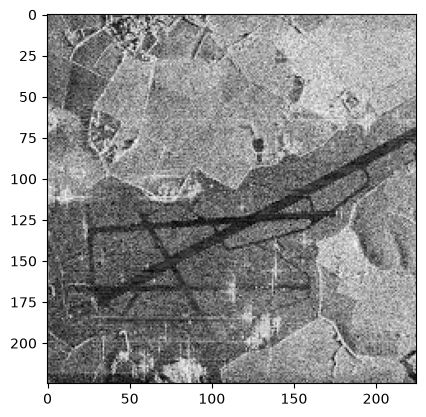

In [26]:
plt.imshow(gray, cmap="gray")

In [27]:
# Задание 1
gray_f = cv2.medianBlur(gray, 5)

In [28]:
edges = cv2.Canny(gray_f, 50, 150)

In [29]:
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=80,
    minLineLength=100,
    maxLineGap=20
)

out = img.copy()
best_line = None
max_len = 0

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line.reshape(-1)
        length = np.hypot(x2 - x1, y2 - y1)
        if length > max_len:
            max_len = length
            best_line = (x1, y1, x2, y2)

    if best_line is not None:
        x1, y1, x2, y2 = best_line
        cv2.line(out, (x1, y1), (x2, y2), (0, 0, 255), 3)
        print(f'Наиболее протяжённый отрезок: длина = {max_len:.1f} px')
        print(f'Координаты: ({x1}, {y1}) — ({x2}, {y2})')

Наиболее протяжённый отрезок: длина = 235.3 px
Координаты: (15, 179) — (223, 69)


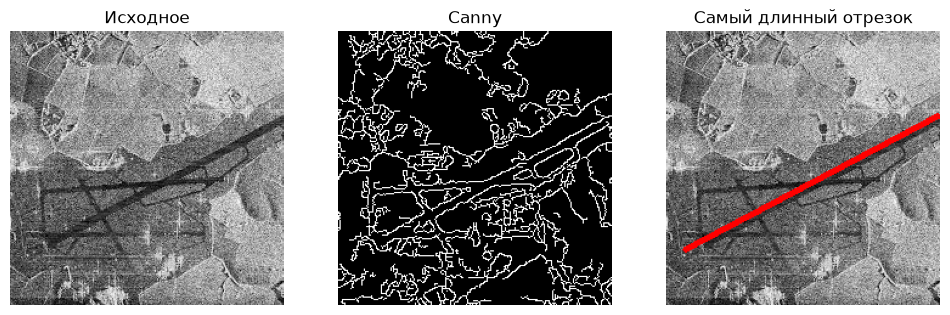

In [30]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Исходное')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.title('Самый длинный отрезок')
plt.axis('off')

plt.show()

In [31]:
# Задание 2
img = cv2.imread('sar_3.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_f = cv2.medianBlur(gray, 5)

In [32]:
_, th_simple = cv2.threshold(gray_f, 100, 255, cv2.THRESH_BINARY_INV)

_, th_otsu = cv2.threshold(
    gray_f, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

th_adapt = cv2.adaptiveThreshold(
    gray_f, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    blockSize=51,
    C=10
)

In [33]:
ret_otsu, _ = cv2.threshold(
    gray_f, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
print(f"Порог, подобранный методом Оцу: {ret_otsu:.2f}\n")

Порог, подобранный методом Оцу: 128.00



In [34]:
def compute_metrics(binary_img, name):
    total_pixels = binary_img.shape[0] * binary_img.shape[1]
    white_pixels = np.count_nonzero(binary_img)
    white_fraction = white_pixels / total_pixels
    num_labels, _ = cv2.connectedComponents(binary_img)
    num_components = num_labels - 1  # исключаем фон
    print(f"{name}:")
    print(f"  доля белых пикселей = {white_fraction:.4f}")
    print(f"  число компонент связности = {num_components}")
    return white_fraction, num_components

In [35]:
print("Сравнение методов бинаризации:")
frac_simple, comp_simple = compute_metrics(th_simple, "Простая бинаризация")
frac_otsu, comp_otsu = compute_metrics(th_otsu, "Метод Оцу")
frac_adapt, comp_adapt = compute_metrics(th_adapt, "Адаптивная бинаризация")

Сравнение методов бинаризации:
Простая бинаризация:
  доля белых пикселей = 0.2605
  число компонент связности = 91
Метод Оцу:
  доля белых пикселей = 0.4684
  число компонент связности = 83
Адаптивная бинаризация:
  доля белых пикселей = 0.2517
  число компонент связности = 333


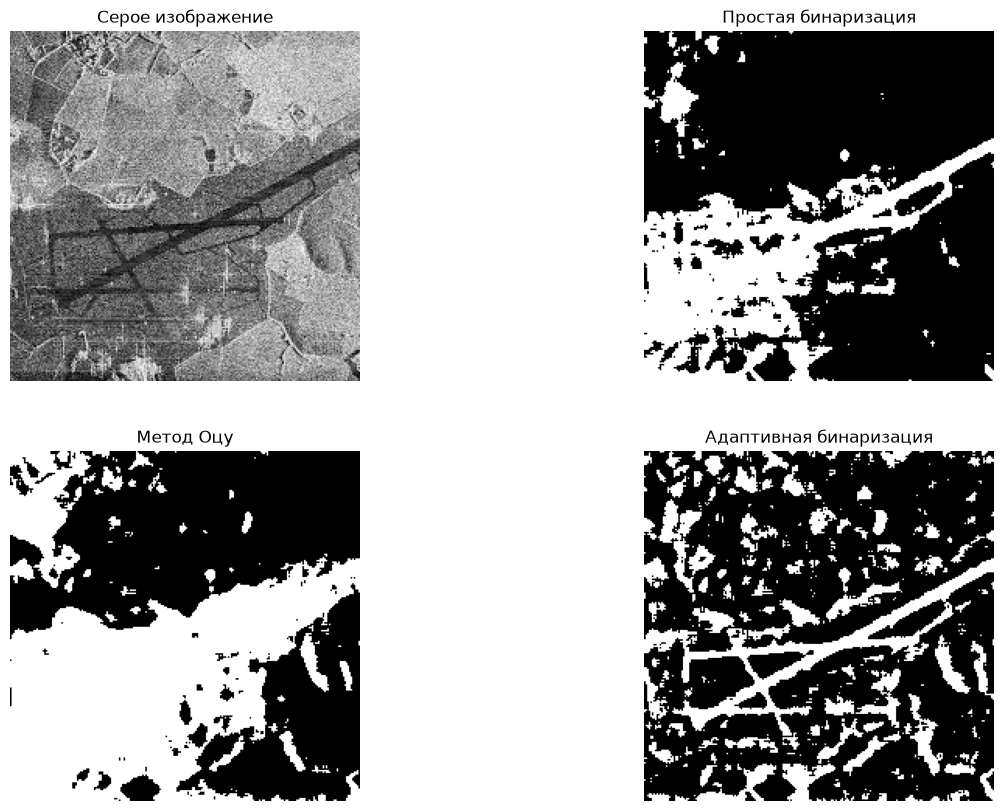

In [36]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Серое изображение')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(th_simple, cmap='gray')
plt.title('Простая бинаризация')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(th_otsu, cmap='gray')
plt.title('Метод Оцу')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(th_adapt, cmap='gray')
plt.title('Адаптивная бинаризация')
plt.axis('off')

plt.show()

In [37]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
bin_road = cv2.morphologyEx(th_otsu, cv2.MORPH_CLOSE, kernel, iterations=2)
bin_road = cv2.morphologyEx(bin_road, cv2.MORPH_OPEN,
                            np.ones((5, 5), np.uint8), iterations=1)

In [38]:
lines_road = cv2.HoughLinesP(
    bin_road,
    rho=1,
    theta=np.pi / 180,
    threshold=60,
    minLineLength=120,
    maxLineGap=40
)

road_mask = np.zeros_like(gray)

if lines_road is not None:
    for line in lines_road:
        x1, y1, x2, y2 = line.reshape(-1)
        length = np.hypot(x2 - x1, y2 - y1)
        if length > 150:
            cv2.line(road_mask, (x1, y1), (x2, y2), 255, 70)

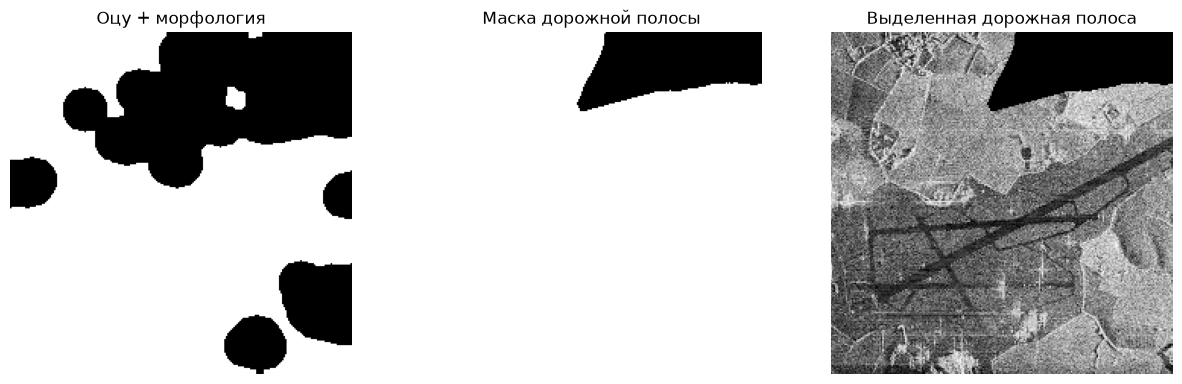

In [39]:
road_strip = cv2.bitwise_and(img, img, mask=road_mask)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(bin_road, cmap='gray')
plt.title('Оцу + морфология')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(road_mask, cmap='gray')
plt.title('Маска дорожной полосы')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(road_strip, cv2.COLOR_BGR2RGB))
plt.title('Выделенная дорожная полоса')
plt.axis('off')

plt.show()

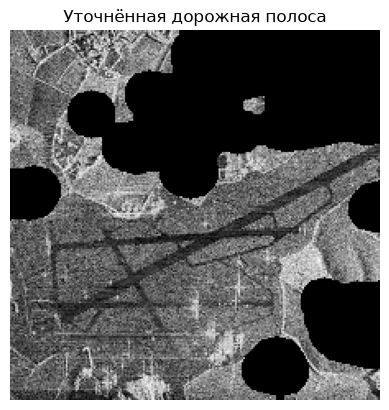

In [40]:
final_mask = cv2.bitwise_and(bin_road, road_mask)
road_strip = cv2.bitwise_and(img, img, mask=final_mask)

plt.imshow(cv2.cvtColor(road_strip, cv2.COLOR_BGR2RGB))
plt.title('Уточнённая дорожная полоса')
plt.axis('off')
plt.show()